# Optimizing an Artificial Neural Network using Optuna

In this notebook, we optimize the ANN model created previously (https://github.com/swethab2113/Learn-PyTorch/blob/main/5_ANN.ipynb)

In [ ]:
# check for GPU
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


If your system does not have GPU, switch to Google Colab which provides it own GPU host (T4). To activate that, go to Runtime > Change runtime type and look for T4 GPU, click okay/save and restart the session.

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 29.0 MB/s eta 0:00:00


### Import essentials

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import optuna

### Set seed for reproducibility

In [ ]:
torch.manual_seed(42)

### Load Fashion MNIST dataset

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("zalando-research/fashionmnist")
files = os.listdir(path)

print("Path to dataset files:", path)
print("Files: \n", files)

Using Colab cache for faster access to the 'fashionmnist' dataset.
Path to dataset files: /kaggle/input/fashionmnist
Files: 
 ['t10k-labels-idx1-ubyte', 't10k-images-idx3-ubyte', 'fashion-mnist_test.csv', 'fashion-mnist_train.csv', 'train-labels-idx1-ubyte', 'train-images-idx3-ubyte']


In [ ]:
data = pd.read_csv(os.path.join(path, 'fashion-mnist_train.csv'))
print(f"Total Samples: ", data.shape[0])
data.head()

Total Samples:  60000


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df = data.copy()
print(f"Total Samples in df: ", df.shape[0])
print(f"Number of features: ", df.iloc[0, 1:].shape[0])
print(f"Number of classes in target: ", df['label'].nunique())
df.head()

Total Samples in df:  60000
Number of features:  784
Number of classes in target:  10


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


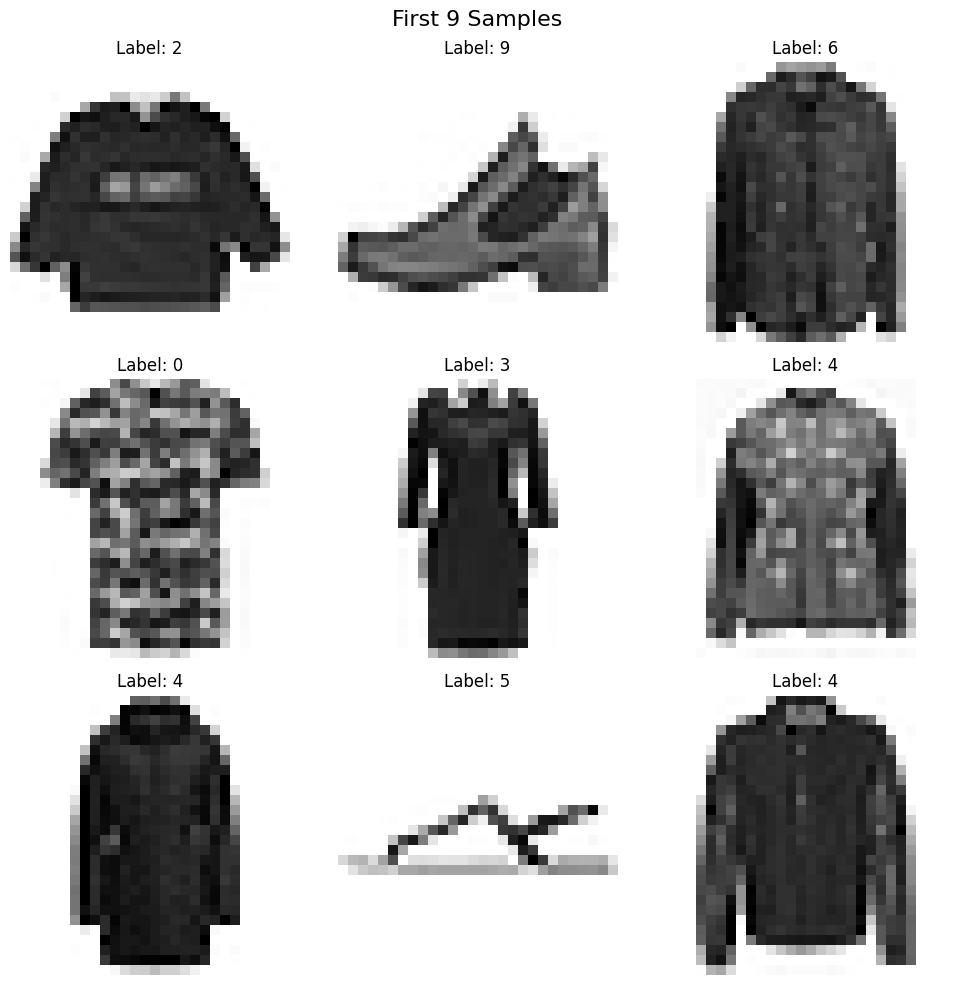

In [ ]:
# images represented in pixels in a row are reshaped to 28 x 28 matrix
# the 28 x 28 matrix is then plotted using matplotlib's imshow function

fig, axes = plt.subplots(3, 3, figsize=(10,10))
fig.suptitle("First 9 Samples", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img, cmap="binary")
    ax.axis("off")
    ax.set_title(f"Label: {df.iloc[i, 0]}")

plt.tight_layout()
plt.show()

### Split data into train and test

In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Scale features

In [ ]:
# pixels range between 0 to 255
X_train = X_train/255.0
X_test = X_test/255.0

### Create CustomDataset class

In [ ]:
class CustomDataset(Dataset):
  def __init__(self, features, target):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.target = torch.tensor(target, dtype=torch.long)

  def __len__(self):
    return self.features.shape[0]

  def __getitem__(self, index):
    return self.features[index], self.target[index]

train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

### Construct neural network

In [ ]:
class ANNModel(nn.Module):
  def __init__(self, in_features, out_features, num_hid_layers, num_neurons, dropout_rate):
    super().__init__()

    layers = []
    for i in range(num_hid_layers):
      layers.append(nn.Linear(in_features, num_neurons))
      layers.append(nn.BatchNorm1d(num_neurons))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      in_features = num_neurons

    layers.append(nn.Linear(in_features, out_features))

    self.network = nn.Sequential(*layers)

  def forward(self, x):
    return self.network(x)



<font color='red'>** **Important Note:** **</font> The softmax activation function is not mentioned explicitly since the cross entropy loss function automatically computes both LogSoftmax and negative log-likelihood loss together in single operation and the model outputs raw unnormalized score called logits.

### Define objective function for Optuna study

In [ ]:
def objective(trial):

  # suggest next hyperparameter value from the search space
  num_hid_layers = trial.suggest_int("num_hid_layers", 1, 5)
  num_neurons = trial.suggest_int("num_neurons", 8, 128, step=8)
  epochs = trial.suggest_int("epochs", 50, 100, step=10)
  learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
  dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
  batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
  optimizer = trial.suggest_categorical("optimizer", ["Adam", "SGD", "RMSprop"])
  weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

  # initialize model
  in_features = 784
  out_targets = 10

  model = ANNModel(in_features, out_targets, num_hid_layers, num_neurons, dropout_rate)
  model = model.to(device)

  # define loss function and optimizer
  loss_func = nn.CrossEntropyLoss()
  if optimizer == "Adam":
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  elif optimizer == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  elif optimizer == "RMSprop":
    optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

  # train model
  for epoch in range(epochs):
    for batch_features, batch_target in train_loader:
      batch_features, batch_target = batch_features.to(device), batch_target.to(device)
      y_pred = model(batch_features)
      loss = loss_func(y_pred, batch_target)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

  # evaluate model
  model.eval()

  total_pred = 0
  correct_pred = 0

  with torch.no_grad():
    for batch_features, batch_target in test_loader:
      batch_features, batch_target = batch_features.to(device), batch_target.to(device)
      y_pred_t = model(batch_features)
      _, predicted = torch.max(y_pred_t, 1)
      total_pred += batch_target.shape[0]
      correct_pred += (predicted == batch_target).sum().item()
    score = correct_pred/total_pred

  return score

### Conduct study

In [ ]:
study = optuna.create_study(direction='maximize')
# maximize accuracy; minimize loss.

[I 2026-09-11 10:28:01,895] A new study created in memory with name: no-name-e2573716-5f06-44d2-8752-53189363e3f5


In [ ]:
study.optimize(objective, n_trials=10)
# number of trials is kept to 10 for simplicity; try running the code at n_trials being 50 or 100.

[I 2026-09-11 11:19:26,382] Trial 11 finished with value: 0.81275 and parameters: {'num_hid_layers': 2, 'num_neurons': 120, 'epochs': 50, 'learning_rate': 0.021881262131823682, 'dropout_rate': 0.4, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 4.653568820053296e-05}. Best is trial 3 with value: 0.8915.
[I 2026-09-11 11:22:23,509] Trial 12 finished with value: 0.8900833333333333 and parameters: {'num_hid_layers': 4, 'num_neurons': 88, 'epochs': 70, 'learning_rate': 2.4916613971564633e-05, 'dropout_rate': 0.1, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 6.0570957840141774e-05}. Best is trial 3 with value: 0.8915.
[I 2026-09-11 11:24:55,123] Trial 13 finished with value: 0.8916666666666667 and parameters: {'num_hid_layers': 4, 'num_neurons': 104, 'epochs': 60, 'learning_rate': 4.710016477968351e-05, 'dropout_rate': 0.1, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.000632818056928113}. Best is trial 13 with value: 0.8916666666666667.
[I 2026-09-11 1

In [ ]:
study.best_value

0.8915

In [ ]:
study.best_params

{'num_hid_layers': 3,
 'num_neurons': 80,
 'epochs': 60,
 'learning_rate': 6.133081214397755e-05,
 'dropout_rate': 0.1,
 'batch_size': 64,
 'optimizer': 'RMSprop',
 'weight_decay': 0.00023089075810732736}